# Introduccion a RNN, LSTM y Transformers

Hasta ahora trabajamos con imagenes, donde el orden de los pixeles importa pero cada imagen es un bloque fijo de datos. El texto es distinto: es una secuencia, y el orden de las palabras cambia el significado. En este notebook vamos a ver, sobre todo a traves de codigo, que problema resuelven las RNN, por que se quedan cortas, y por que eso llevo a la creacion de los Transformers.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

## 1. Por que el orden importa

Si representamos una oracion como un conjunto de palabras (sin orden), perdemos informacion clave.

In [ ]:
oracion_a = "el perro persigue al gato"
oracion_b = "el gato persigue al perro"

bolsa_a = set(oracion_a.split()) # .split() divide una cadena de texto en una lista de palabras ; set() convierte la lista en un conjunto de elementos únicos
bolsa_b = set(oracion_b.split())

print("Mismas palabras:", bolsa_a == bolsa_b)
print("Mismo significado:", oracion_a == oracion_b)

Mismas palabras: True
Mismo significado: False


Las mismas palabras, dos significados distintos. Un modelo que no tenga en cuenta el orden (como una capa `Dense` normal recibiendo las palabras sueltas) no puede distinguir estas dos oraciones. Necesitamos una arquitectura que procese la secuencia en orden.

## 2. La idea de una RNN: memoria que se actualiza paso a paso

Una RNN (Red Neuronal Recurrente) lee la secuencia de a un elemento por vez. En cada paso, combina el elemento actual con un "estado oculto" (`h`), que funciona como una memoria de todo lo que proceso hasta ese momento:  

$
h_t = tanh(Wx * x_t + Wh * h_(t-1) + b)
$  

Vamos a programar esto a mano, paso a paso, sobre una oracion chiquita representada con vectores one-hot.

In [ ]:
vocabulario = ["el", "gato", "persigue", "al", "perro"]
tam_vocabulario = len(vocabulario)

# Cada palabra como un vector one-hot (5 palabras -> vectores de tamano 5)
X = np.eye(tam_vocabulario) # genera una matriz identidad de tamaño "tam_vocabulario" (forma rapida de hacer one-hot encoding)

# Configuración de la capa oculta (memoria de la RNN)
tam_oculto = 3  # Tamaño del estado oculto/memoria h_t (3 neuronas en este ejemplo)

np.random.seed(0)
Wx = np.random.randn(tam_oculto, tam_vocabulario) * 0.5 # Pesos para la entrada actual (x_t)
Wh = np.random.randn(tam_oculto, tam_oculto) * 0.5 # Pesos para la memoria anterior (h_{t-1})
b = np.zeros(tam_oculto) # Sesgo (bias) inicializado en ceros

h = np.zeros(tam_oculto)  # Hidden state inicial: no hay memoria todavia
historial_h = []

# Forward Pass a lo largo de la secuencia temporal
for t, palabra in enumerate(vocabulario):
    x_t = X[t] # Extrae el vector one-hot de la palabra actual en el paso t
    # Ecuación fundamental de la RNN: combina la entrada actual x_t con la memoria anterior h
    # tanh comprime los valores del nuevo estado en el rango [-1, 1]
    h = np.tanh(Wx @ x_t + Wh @ h + b)  # El nuevo estado depende de la palabra actual Y del estado anterior
    historial_h.append(h.copy()) # Almacena una copia del estado oculto actual
    print(f"Paso {t} ({palabra}): h = {np.round(h, 2)}")

historial_h = np.array(historial_h)

Paso 0 (el): h = [ 0.71 -0.45  0.07]
Paso 1 (gato): h = [-0.03  0.6   0.63]
Paso 2 (persigue): h = [ 0.7  -0.81  0.38]
Paso 3 (al): h = [ 0.53 -0.08 -0.2 ]
Paso 4 (perro): h = [0.76 0.52 0.41]


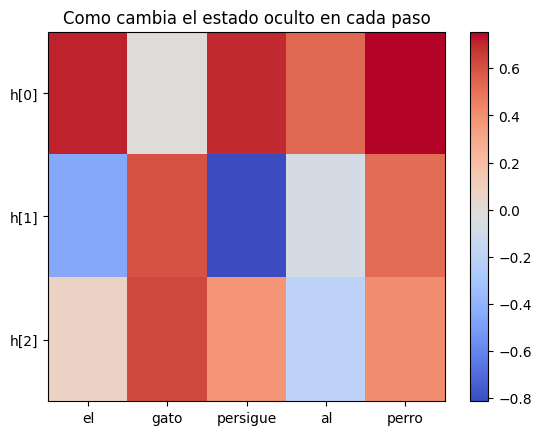

In [ ]:
plt.imshow(historial_h.T, cmap="coolwarm", aspect="auto")
plt.yticks(range(tam_oculto), [f"h[{i}]" for i in range(tam_oculto)])
plt.xticks(range(len(vocabulario)), vocabulario)
plt.title("Como cambia el estado oculto en cada paso")
plt.colorbar()
plt.show()

Cada columna es el estado oculto despues de leer una palabra nueva. Ese vector cambia en cada paso porque arrastra informacion de todas las palabras anteriores. Esa es la idea central de una RNN: una memoria que se va actualizando a medida que avanza la secuencia.

## 3. El limite de las RNN: el gradiente que se desvanece

Para ver por que a una RNN simple le cuesta recordar informacion de muchos pasos atras, vamos a medir algo muy concreto: cuanto sobrevive el gradiente cuando viaja desde el final de una secuencia hasta el primer paso.

Durante el entrenamiento (backpropagation through time), ese gradiente es lo que le dice a la red "que tanto ajustar los pesos que procesaron el primer paso, para mejorar la prediccion final". Si ese gradiente se hace practicamente cero, la red no tiene forma de aprender a usar informacion de pasos lejanos, sin importar cuantas epocas entrenemos. Vamos a calcularlo directamente, sin necesidad de entrenar ningun modelo.

In [ ]:
# Esta función simula una RNN durante una secuencia y
# mide qué tan grande queda el gradiente después de atravesar todos los pasos temporales

def norma_gradiente_rnn(largo_secuencia, unidades=16, n_pruebas=20):
  # largo_secuencia: cantidad de pasos temporales; unidades: tamaño del hidden state; n_pruebas: cantidad de pruebas
    normas = []
    for prueba in range(n_pruebas):
        rng = np.random.default_rng(prueba)
        Wx = rng.normal(0, 1 / np.sqrt(unidades), size=(unidades, 1))
        Wh, _ = np.linalg.qr(rng.normal(size=(unidades, unidades)))  # igual que Keras: recurrente ortogonal
        x = rng.integers(0, 2, size=(largo_secuencia, 1)).astype(float)

        h = np.zeros(unidades)
        jacobiano_acumulado = np.eye(unidades)  # representa d h_final / d h_0

        for t in range(largo_secuencia):
            z = Wx @ x[t] + Wh @ h
            h = np.tanh(z)
            derivada_tanh = 1 - h ** 2
            jacobiano_paso = derivada_tanh[:, None] * Wh  # regla de la cadena de este paso
            jacobiano_acumulado = jacobiano_paso @ jacobiano_acumulado

        normas.append(np.linalg.norm(jacobiano_acumulado, ord=2))
    return np.mean(normas)

In [ ]:
largos = [5, 10, 20, 40, 60, 80, 100] # Definimos diferentes longitudes de secuencia para probar (podria ser oraciones)
normas_rnn = [norma_gradiente_rnn(largo) for largo in largos] # # Calculamos la norma del gradiente para cada longitud


for largo, norma in zip(largos, normas_rnn): # Recorremos cada longitud junto con su norma del gradiente
    print(f"largo {largo:>4}: norma del gradiente = {norma:.3f}")

largo    5: norma del gradiente = 0.928
largo   10: norma del gradiente = 0.698
largo   20: norma del gradiente = 0.327
largo   40: norma del gradiente = 0.067
largo   60: norma del gradiente = 0.014
largo   80: norma del gradiente = 0.003
largo  100: norma del gradiente = 0.001


El gradiente se achica rapidamente a medida que la secuencia se alarga: a los 100 pasos, es varios ordenes de magnitud mas chico que al principio. Esto pasa incluso con pesos elegidos al azar, antes de entrenar nada: es una propiedad estructural de la RNN simple, no un accidente de un entrenamiento particular.

## 4. LSTM y GRU: una compuerta para decidir que conservar

La idea central de LSTM y GRU es agregar una **compuerta de olvido** (`forget gate`): en vez de mezclar el estado anterior con la entrada nueva y una no-linealidad en *cada* paso, la celda puede optar por conservar una fraccion del estado anterior casi intacta. Si esa fraccion es cercana a 1, la informacion sobrevive casi sin perdida, sin importar cuantos pasos pasen.

Lo importante es que esa fraccion es un parametro mas, que el entrenamiento puede aprender a ajustar. Comparemos que pasa con una compuerta "baja" (una red que todavia no aprendio a recordar) contra una compuerta "alta" (una red que ya aprendio).

In [ ]:
def supervivencia_con_compuerta(largo_secuencia, valor_compuerta):
    return valor_compuerta ** largo_secuencia  # que fraccion de la señal original sobrevive despues de N pasos


supervivencia_compuerta_baja = [supervivencia_con_compuerta(largo, 0.7) for largo in largos]
supervivencia_compuerta_alta = [supervivencia_con_compuerta(largo, 0.98) for largo in largos]

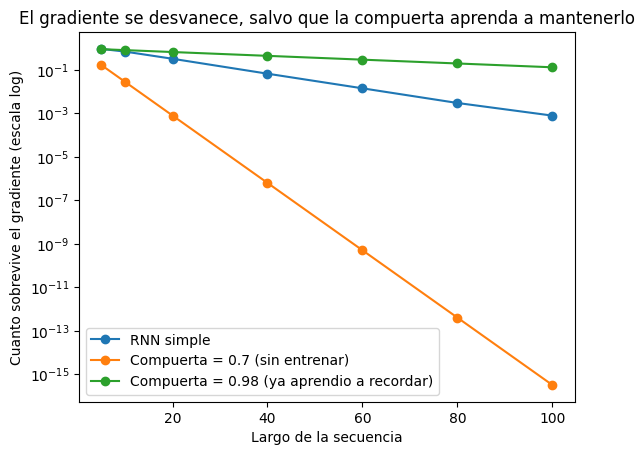

In [ ]:
plt.plot(largos, normas_rnn, marker="o", label="RNN simple")
plt.plot(largos, supervivencia_compuerta_baja, marker="o", label="Compuerta = 0.7 (sin entrenar)")
plt.plot(largos, supervivencia_compuerta_alta, marker="o", label="Compuerta = 0.98 (ya aprendio a recordar)")
plt.yscale("log")
plt.xlabel("Largo de la secuencia")
plt.ylabel("Cuanto sobrevive el gradiente (escala log)")
plt.title("El gradiente se desvanece, salvo que la compuerta aprenda a mantenerlo")
plt.legend()
plt.show()

Con compuerta baja (0.7), la señal se pierde incluso mas rapido que en la RNN simple: tener una compuerta no ayuda por si sola. Lo que marca la diferencia es que esa compuerta pueda **aprender** a acercarse a 1 cuando la tarea lo necesita. Con compuerta alta (0.98), a los 100 pasos todavia sobrevive una fraccion notable de la señal original -- varios ordenes de magnitud mas que la RNN simple.

Esa es la ventaja estructural de LSTM y GRU: tienen una perilla independiente para "cuanto conservar", separada de los calculos que procesan la entrada nueva. Una RNN simple no tiene esa perilla; su capacidad de recordar esta atada a los mismos pesos que hacen todo lo demas, y por eso no puede ajustarla de forma independiente durante el entrenamiento.

## 5. El siguiente problema: seguir leyendo de a un paso por vez

Tanto la RNN como la LSTM comparten una limitacion estructural: para saber que paso en la palabra 50, primero hay que procesar las 49 anteriores, una por una. Esto es lento (no se puede paralelizar) y hace que la informacion de pasos muy lejanos tenga que sobrevivir un camino muy largo antes de llegar a donde se la necesita.

La idea de los Transformers es distinta: en vez de pasar la informacion paso a paso por una memoria, cada palabra puede mirar directamente a todas las demas palabras de la secuencia, en un solo paso. Este mecanismo se llama **atencion**.

## 6. Atencion, programada a mano

La version simplificada del mecanismo de atencion (scaled dot-product attention) hace esto:

1. A cada palabra se le calculan tres vectores: `Query` (que estoy buscando), `Key` (que puedo ofrecer) y `Value` (la informacion que aporto).
2. Se comparan la `Query` de cada palabra con la `Key` de todas las demas (producto punto), para obtener un puntaje de "cuanto me interesa esa palabra".
3. Esos puntajes pasan por un `softmax` para convertirse en pesos que suman 1.
4. La salida de cada palabra es el promedio ponderado de los `Value` de todas las palabras, usando esos pesos.

Nota: los vectores de esta seccion son aleatorios (no entrenados), asi que los pesos de atencion no van a tener un patron con sentido linguistico todavia. Lo que nos interesa es el mecanismo, no el resultado.

In [ ]:
palabras = ["el", "gato", "persigue", "al", "perro"]  # Definimos las palabras de nuestra secuencia
n = len(palabras)  # Calculamos cuántas palabras tenemos
dim = 4  # Definimos la dimensión de los vectores; usamos una dimensión pequeña para facilitar el ejemplo


np.random.seed(1)  # Fijamos la semilla
X_palabras = np.random.randn(n, dim)  # Creamos embeddings inventados para representar cada palabra


Wq = np.random.randn(dim, dim) * 0.5  # Creamos los weights para construir los Query
Wk = np.random.randn(dim, dim) * 0.5  # Creamos los weights para construir los Key
Wv = np.random.randn(dim, dim) * 0.5  # Creamos los weights para construir los Value


Q = X_palabras @ Wq  # Transformamos los embeddings en Query
K = X_palabras @ Wk  # Transformamos los embeddings en Key
V = X_palabras @ Wv  # Transformamos los embeddings en Value


puntajes = (Q @ K.T) / np.sqrt(dim)  # Calculamos cuánto debe prestar atención cada palabra a las demás


def softmax(x, eje=-1):
    exp = np.exp(x - np.max(x, axis=eje, keepdims=True))  # Convertimos los puntajes en valores positivos y evitamos números demasiado grandes
    return exp / np.sum(exp, axis=eje, keepdims=True)  # Normalizamos los valores para convertirlos en probabilidades que suman 1


pesos_atencion = softmax(puntajes)  # Convertimos los puntajes en pesos de atención
salida_atencion = pesos_atencion @ V  # Combinamos los Values según la atención que recibió cada palabra


print(
    "Los pesos de atencion de cada fila suman 1:",
    np.round(pesos_atencion.sum(axis=1), 2)
)  # Comprobamos que los pesos de atención de cada palabra suman 1

Los pesos de atencion de cada fila suman 1: [1. 1. 1. 1. 1.]


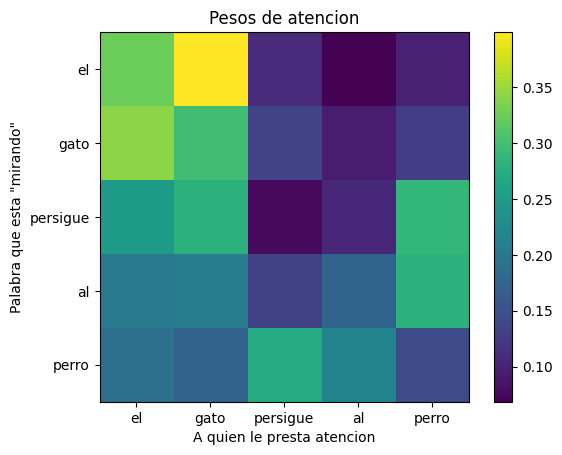

In [ ]:
plt.imshow(pesos_atencion, cmap="viridis")
plt.xticks(range(n), palabras)
plt.yticks(range(n), palabras)
plt.xlabel("A quien le presta atencion")
plt.ylabel("Palabra que esta \"mirando\"")
plt.title("Pesos de atencion")
plt.colorbar()
plt.show()

Cada fila muestra, para una palabra dada, cuanto peso le pone a cada una de las otras palabras de la oracion (incluida ella misma). La diferencia clave con la RNN: esto se calcula en un solo paso, comparando todas las palabras entre si directamente, sin tener que pasar por una cadena de estados ocultos. Cuando estos vectores se entrenan de verdad (como en un Transformer real), esos pesos aprenden a reflejar relaciones utiles del lenguaje, como que palabra se relaciona con cual otra.

Keras ya trae este mecanismo implementado como una capa, por si en algun momento necesitas usarlo dentro de un modelo real, sin tener que escribir la operacion a mano:

In [ ]:
capa_atencion = layers.MultiHeadAttention(num_heads=2, key_dim=dim)
print(capa_atencion)

<MultiHeadAttention name=multi_head_attention, built=False>


Mira este video para comprender intuitivamente el concepto de atención:  
https://www.youtube.com/watch?v=RNF0FvRjGZk

## Resumen

- **RNN**: lee la secuencia paso a paso y mantiene un estado oculto como memoria. Funciona bien en secuencias cortas, pero tiende a olvidar informacion de pasos lejanos.
- **LSTM**: agrega gates que deciden que recordar y que olvidar, lo que le permite sostener memoria por mas pasos. Sigue siendo secuencial (lenta de entrenar, dificil de paralelizar).
- **Transformer**: reemplaza la memoria paso a paso por atencion, donde cada palabra puede mirar directamente a cualquier otra palabra de la secuencia, sin importar la distancia, en un solo paso. Esto es mas facil de paralelizar y maneja mejor las dependencias largas.

Los Transformers son la arquitectura detras de los modelos de lenguaje actuales (GPT, BERT, y similares). Todo lo que programaste a mano en este notebook -- el estado oculto de la RNN, los gates de la LSTM (conceptualmente), y el mecanismo de atencion -- son, en el fondo, la misma idea que usan esos modelos, solo que a una escala mucho mayor.